<a href="https://colab.research.google.com/github/Jayantsinghkhanna/UCS547-ACCELERATED-DATA-SCIENCE-LAB/blob/main/Assignment_6_Accelerated_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1 — Adult Census Income Dataset
GPU Histogram Binning + Model Training

In [1]:
!pip install -q cudf-cu12 cuml-cu12 \
cupy-cuda12x xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import cupy as cp
import cudf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier

from cuml.ensemble import RandomForestClassifier as cuRF

from xgboost import XGBClassifier

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [

    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'

]

df = pd.read_csv(
    url,
    names=columns,
    na_values=' ?'
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
continuous = [

    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'

]

categorical = [

    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'

]

binary = ['income']

print("Continuous Features:")
print(continuous)

print("\nCategorical Features:")
print(categorical)

print("\nBinary Feature:")
print(binary)

Continuous Features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical Features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Binary Feature:
['income']


In [5]:
df = df.dropna()

encoder = LabelEncoder()

for col in categorical + binary:

    df[col] = encoder.fit_transform(
        df[col]
    )

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,0


In [8]:
# ============================================================
# GPU HISTOGRAM BINNING
# ============================================================

gpu_df = cudf.from_pandas(df)

feature = 'age'

gpu_array = cp.asarray(
    gpu_df[feature]
)

gpu_hist, gpu_bins = cp.histogram(
    gpu_array,
    bins=10
)

cpu_hist, cpu_bins = np.histogram(
    df[feature],
    bins=10
)

print("GPU Histogram:")
print(cp.asnumpy(gpu_hist))

print("\nCPU Histogram:")
print(cpu_hist)

GPU Histogram:
[4869 5579 5761 5925 3810 2412 1278  359  114   55]

CPU Histogram:
[4869 5579 5761 5925 3810 2412 1278  359  114   55]


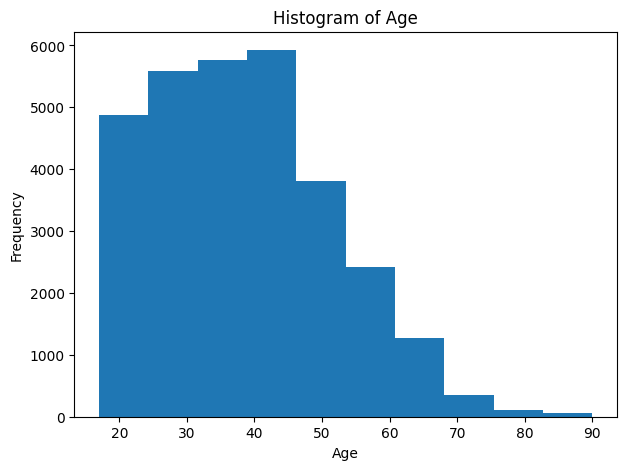

In [9]:
plt.figure(figsize=(7,5))

plt.hist(
    df['age'],
    bins=10
)

plt.title("Histogram of Age")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

In [10]:
quantiles = cp.percentile(

    gpu_array,

    [0,25,50,75,100]

)

print("Quantile Bin Edges:")

print(cp.asnumpy(quantiles))

Quantile Bin Edges:
[17. 28. 37. 47. 90.]


In [11]:
X = df.drop(
    'income',
    axis=1
)

y = df['income']

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [12]:
start_cpu = time.time()

cpu_model = RandomForestClassifier(

    n_estimators=100,
    random_state=42

)

cpu_model.fit(
    X_train,
    y_train
)

cpu_train_time = time.time() - start_cpu

start_pred = time.time()

cpu_pred = cpu_model.predict(X_test)

cpu_pred_time = time.time() - start_pred

cpu_acc = accuracy_score(
    y_test,
    cpu_pred
)

print("CPU Accuracy:",
      round(cpu_acc,4))

CPU Accuracy: 0.8553


In [13]:
X_train_gpu = cudf.from_pandas(
    X_train
)

X_test_gpu = cudf.from_pandas(
    X_test
)

y_train_gpu = cudf.Series(
    y_train.values
)

start_gpu = time.time()

gpu_model = cuRF(

    n_estimators=100,

    random_state=42

)

gpu_model.fit(
    X_train_gpu,
    y_train_gpu
)

gpu_train_time = time.time() - start_gpu

gpu_pred = gpu_model.predict(
    X_test_gpu
)

gpu_acc = accuracy_score(

    y_test,

    gpu_pred.to_numpy()

)

print("GPU Accuracy:",
      round(gpu_acc,4))

GPU Accuracy: 0.8631


In [14]:
speedup = cpu_train_time / gpu_train_time

print("GPU Speedup:",
      round(speedup,2),
      "x")

GPU Speedup: 0.99 x


In [18]:
# ============================================================
# XGBOOST GPU
# ============================================================

xgb_model = XGBClassifier(

    tree_method='hist',

    device='cuda',

    max_depth=6,

    n_estimators=100,

    random_state=42

)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost GPU Accuracy:",
      round(xgb_acc,4))

XGBoost GPU Accuracy: 0.8694


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:18:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [19]:
results = pd.DataFrame({

    'Model': [

        'CPU RF',
        'GPU RF',
        'XGBoost GPU'

    ],

    'Accuracy': [

        cpu_acc,
        gpu_acc,
        xgb_acc

    ]
})

print(results)

         Model  Accuracy
0       CPU RF  0.855296
1       GPU RF  0.863086
2  XGBoost GPU  0.869385


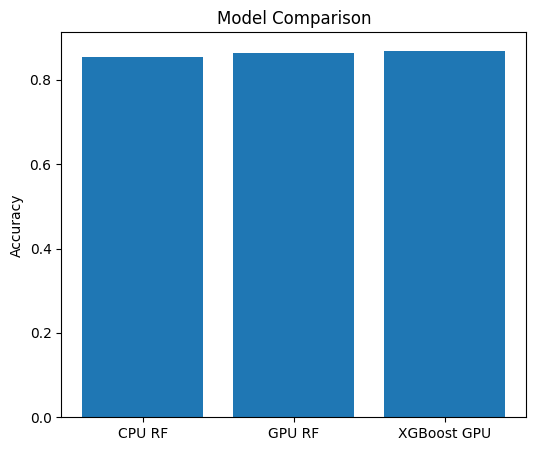

In [20]:
plt.figure(figsize=(6,5))

plt.bar(

    ['CPU RF','GPU RF','XGBoost GPU'],

    [cpu_acc,gpu_acc,xgb_acc]

)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

Q2 — Breast Cancer Datase

In [21]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(

    data.data,

    columns=data.feature_names

)

y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [22]:
start_cpu = time.time()

cpu_rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

cpu_rf.fit(
    X_train,
    y_train
)

cpu_time = time.time() - start_cpu

cpu_pred = cpu_rf.predict(
    X_test
)

cpu_acc = accuracy_score(
    y_test,
    cpu_pred
)

print("CPU Accuracy:",
      round(cpu_acc,4))

CPU Accuracy: 0.9649


In [23]:
X_train_gpu = cudf.from_pandas(
    X_train
)

X_test_gpu = cudf.from_pandas(
    X_test
)

y_train_gpu = cudf.Series(
    y_train.values
)

start_gpu = time.time()

gpu_rf = cuRF(

    n_estimators=100,

    random_state=42

)

gpu_rf.fit(
    X_train_gpu,
    y_train_gpu
)

gpu_time = time.time() - start_gpu

gpu_pred = gpu_rf.predict(
    X_test_gpu
)

gpu_acc = accuracy_score(

    y_test,

    gpu_pred.to_numpy()

)

print("GPU Accuracy:",
      round(gpu_acc,4))

GPU Accuracy: 0.9649


In [24]:
speedup = cpu_time / gpu_time

print("GPU Speedup:",
      round(speedup,2),
      "x")

GPU Speedup: 1.15 x


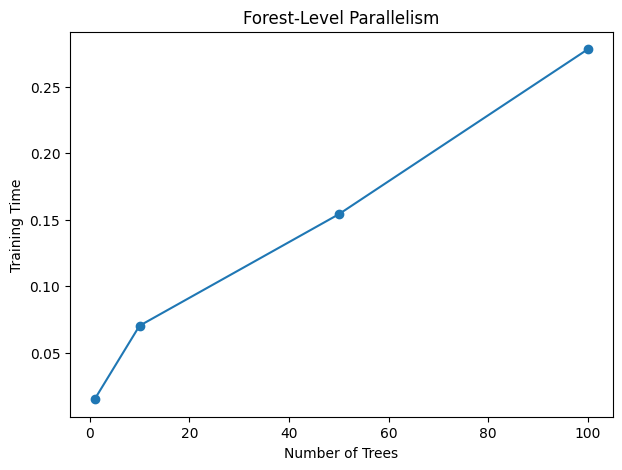

In [25]:
estimators = [1,10,50,100]

times = []

for n in estimators:

    start = time.time()

    model = cuRF(
        n_estimators=n
    )

    model.fit(
        X_train_gpu,
        y_train_gpu
    )

    times.append(
        time.time() - start
    )

plt.figure(figsize=(7,5))

plt.plot(
    estimators,
    times,
    marker='o'
)

plt.xlabel("Number of Trees")

plt.ylabel("Training Time")

plt.title("Forest-Level Parallelism")

plt.show()

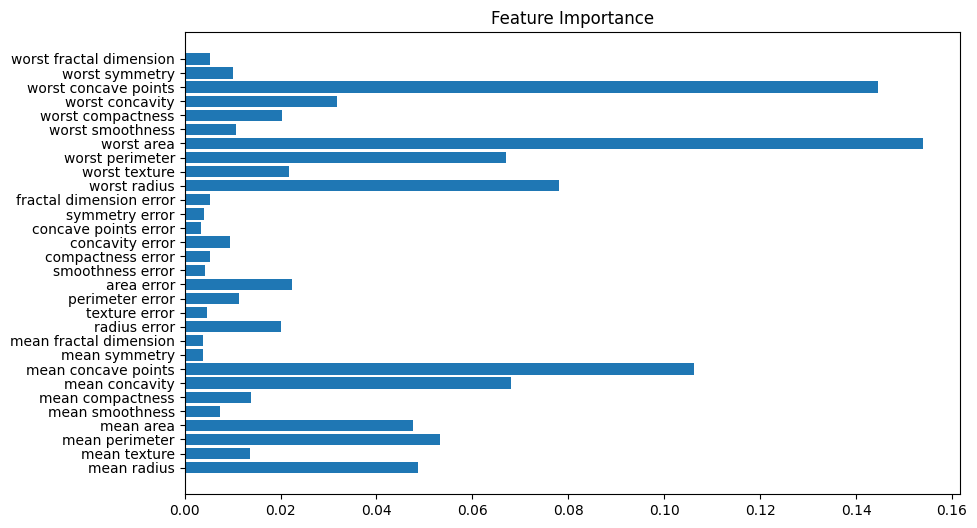

In [26]:
importance = cpu_rf.feature_importances_

plt.figure(figsize=(10,6))

plt.barh(
    X.columns,
    importance
)

plt.title("Feature Importance")

plt.show()

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


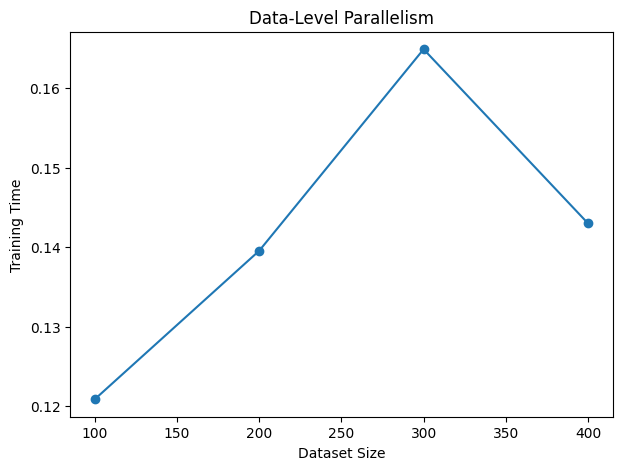

In [27]:
sizes = [100,200,300,400]

times = []

for size in sizes:

    X_small = X_train_gpu.iloc[:size]

    y_small = y_train_gpu.iloc[:size]

    start = time.time()

    model = cuRF(
        n_estimators=50
    )

    model.fit(
        X_small,
        y_small
    )

    times.append(
        time.time() - start
    )

plt.figure(figsize=(7,5))

plt.plot(
    sizes,
    times,
    marker='o'
)

plt.xlabel("Dataset Size")

plt.ylabel("Training Time")

plt.title("Data-Level Parallelism")

plt.show()

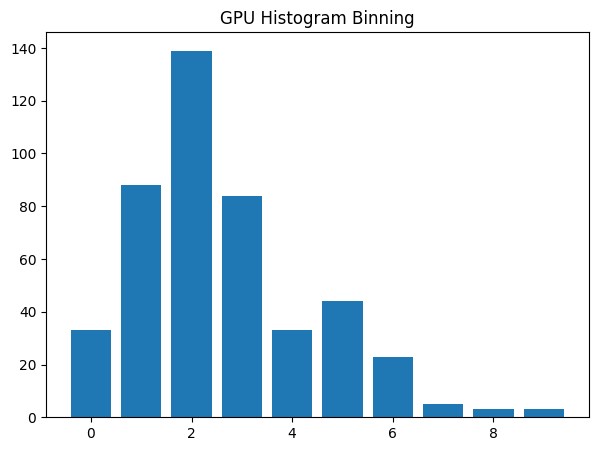

In [28]:
gpu_feature = cp.asarray(
    X_train['mean radius']
)

hist, bins = cp.histogram(
    gpu_feature,
    bins=10
)

plt.figure(figsize=(7,5))

plt.bar(

    range(len(cp.asnumpy(hist))),

    cp.asnumpy(hist)

)

plt.title("GPU Histogram Binning")

plt.show()

In [29]:
comparison = pd.DataFrame({

    'Implementation': [

        'CPU RF',
        'GPU RF'

    ],

    'Accuracy': [

        cpu_acc,
        gpu_acc

    ],

    'Training Time': [

        cpu_time,
        gpu_time

    ]
})

print(comparison)

  Implementation  Accuracy  Training Time
0         CPU RF  0.964912       0.394599
1         GPU RF  0.964912       0.341860


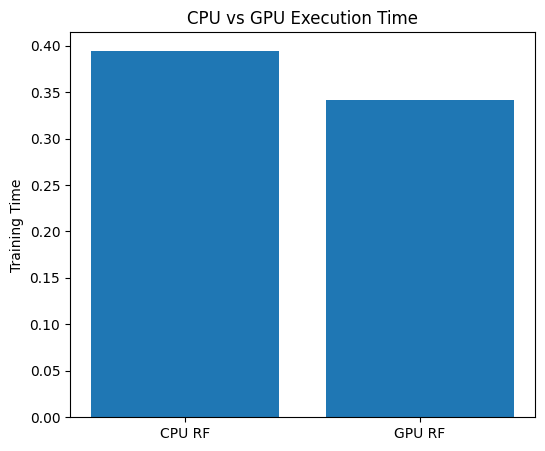

In [30]:
plt.figure(figsize=(6,5))

plt.bar(

    ['CPU RF','GPU RF'],

    [cpu_time,gpu_time]

)

plt.ylabel("Training Time")

plt.title("CPU vs GPU Execution Time")

plt.show()